In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
from typing import Dict, List, Optional
import textwrap
import numpy as np

from jupyter_lsp.specs import md
from patsy.highlevel import dmatrix

In [2]:
def reshape_df(df, valname):
    sim_col = df.columns[0]
    time_cols = df.columns[1:]
    long_df = df.melt(
        id_vars=sim_col,
        value_vars=time_cols,
        var_name='time index',
        value_name=valname
    )
    return long_df

In [3]:
def _detect_value_col(df_long: pd.DataFrame, sim_col: str) -> str:
    non_vals = {sim_col, 'time index'}
    value_cols = [c for c in df_long.columns if c not in non_vals]
    if len(value_cols) != 1:
        raise ValueError(f"Could not uniquely identify value column. Found: {value_cols}")
    return value_cols[0]


def make_per_regime_aggregates(
    df_long: pd.DataFrame,
    sim_col: str,
    bases: List[str],
    agg_label: str,
    regimes: List[str] = ['mm', 'md', 'dm', 'dd'],
    method: str = 'pool',   # "pool" or "per-sim-median"
) -> Optional[pd.DataFrame]:

    if not bases:
        return None

    val_col = _detect_value_col(df_long, sim_col)
    out = []

    # Build a regex that matches any of the bases, with the regime at the END
    # Examples matched: "moderateCAPE-set1-mm"
    base_alt = "|".join(map(re.escape, bases))
    for r in regimes:
        pattern = rf"^(?:{base_alt})-{r}$"
        subset = df_long[df_long[sim_col].str.match(pattern, na=False)].copy()
        if subset.empty:
            continue

        newname = f"{agg_label}-{r}"

        if method == "per-sim-median":
            # One value per simulation (median across its timesteps), then pool
            per_sim = (subset.groupby(sim_col, as_index=False)[val_col].mean())#.median())
            per_sim[sim_col] = newname
            per_sim['time index'] = 'per-sim-median'
            subset = per_sim[[sim_col, 'time index', val_col]]
        else:
            # Pool all timesteps across all matched sims for this regime
            subset[sim_col] = newname

        out.append(subset)

    if not out:
        return None
    return pd.concat(out, ignore_index=True)


def append_aggregates_from_specs(
    df_long: pd.DataFrame,
    sim_col: str,
    specs: Dict[str, List[str]],
    regimes: List[str] = ['mm', 'md', 'dm', 'dd'],
    method: str = 'pool',
) -> pd.DataFrame:

    frames = [df_long]
    for agg_label, bases in specs.items():
        agg_df = make_per_regime_aggregates(
            df_long, sim_col, bases, agg_label, regimes=regimes, method=method
        )
        if agg_df is not None:
            frames.append(agg_df)
    return pd.concat(frames, ignore_index=True)

In [4]:
def tag_group(sim_name: str) -> str:
    s = str(sim_name).lower()
    m = re.search(r'(mm|md|dm|dd)', s)
    return m.group(1) if m else 'other'

In [5]:
inpath = Path('/storm/topping/cold_pools/sim_means')

In [8]:
b = pd.read_csv(inpath / 'buoyancy_means_const_thresh.csv', header=None)
b = reshape_df(b, 'Buoyancy')

area = pd.read_csv(inpath / 'areas.csv', header=None)
area = reshape_df(area, 'Cold Pool Area')
area['Cold Pool Area'] = area['Cold Pool Area']

depth = pd.read_csv(inpath / 'depth_means_const_thresh.csv', header=None)
depth = reshape_df(depth, 'Cold Pool Depth')

prate = pd.read_csv(inpath / 'prate_means_const_thresh.csv', header=None)
prate = reshape_df(prate, 'Surface Precipitation Rate')

lh_norm = pd.read_csv(inpath / 'lh_norm_means_500m.csv', header=None)
lh_norm = reshape_df(lh_norm, 'Normalized Latent Heating')

In [9]:
AGG_SPECS = {
    'moderateCAPE-agg': [
        # '2500_core',
        'moderateCAPE-set1',
        'moderateCAPE-set2',
        'moderateCAPE-set3',
        'moderateCAPE-set4'
    ],
    'highCAPE-agg': [
        '3500_core',
        'highCAPE-set1',
        'highCAPE-set2',
        'highCAPE-set3',
        'highCAPE-set4'
    ],
    'lowCAPE-agg': [
        '1500_core',
        'lowCAPE-set1',
        'lowCAPE-set2'
    ],
    'randomPert-agg': [
        'random_pert-set1',
        'random_pert-set2',
        'random_pert-set3',
        'random_pert-set4',
        'random_pert-set5',
    ]
}

AGG_METHOD = 'per-sim-median'
#AGG_METHOD = 'pool'

sim_col = b.columns[0]

b       = append_aggregates_from_specs(b,       sim_col, AGG_SPECS, method=AGG_METHOD)
area    = append_aggregates_from_specs(area,    sim_col, AGG_SPECS, method=AGG_METHOD)
depth   = append_aggregates_from_specs(depth,   sim_col, AGG_SPECS, method=AGG_METHOD)
prate   = append_aggregates_from_specs(prate,   sim_col, AGG_SPECS, method=AGG_METHOD)
lh_norm = append_aggregates_from_specs(lh_norm, sim_col, AGG_SPECS, method=AGG_METHOD)

In [10]:
sim_col = b.columns[0]   # first column (simulation name)
val_col = 'Buoyancy'     # value column

unique_sims = b[sim_col].unique().tolist()
sim_to_group = {sim: tag_group(sim) for sim in unique_sims}

group_to_color = {
    'mm':   'cornflowerblue',  # blue
    'md':   'cornflowerblue',  # green
    'dm':   'orange',  # orange
    'dd':   'orange',  # red
    'other':'#7f7f7f',  # gray (fallback if pattern not found)
}
group_to_hatch = {
    'mm': '',
    'md': '///',
    'dm': '',
    'dd': '///',
    'other': '',
}
group_long_names = {
    'mm': 'MOIST PBL / MOIST FT',
    'md': 'MOIST PBL / DRY FT',
    'dm': 'DRY PBL / MOIST FT',
    'dd': 'DRY PBL / DRY FT',
    'other': 'NONE',
}

sim_palette = {sim: group_to_color[sim_to_group[sim]] for sim in unique_sims}

In [11]:
BLOCKS = [
    [
    '2500_core-mm',
    '2500_core-md',
    '2500_core-dm',
    '2500_core-dd'
    ],

    [
    'moderateCAPE-agg-mm',
    'moderateCAPE-agg-md',
    'moderateCAPE-agg-dm',
    'moderateCAPE-agg-dd'
    ],

    [
    'highCAPE-agg-mm',
    'highCAPE-agg-md',
    'highCAPE-agg-dm',
    'highCAPE-agg-dd'
    ],

    [
    'lowCAPE-agg-mm',
    'lowCAPE-agg-md',
    'lowCAPE-agg-dm',
    'lowCAPE-agg-dd'
    ],

    [
    'morrison-mm',
    'morrison-md',
    'morrison-dm',
    'morrison-dd'
    ],

    [
    'nssl3-mm',
    'nssl3-md',
    'nssl3-dm',
    'nssl3-dd'
    ],

    [
    'randomPert-agg-mm',
    'randomPert-agg-md',
    'randomPert-agg-dm',
    'randomPert-agg-dd'
    ],

    [
    'freeslip-mm',
    'freeslip-md',
    'freeslip-dm',
    'freeslip-dd'
    ],

    [
    'sigtor-mm',
    'sigtor-md',
    'sigtor-dm',
    'sigtor-dd'
    ]
]


BLOCK_LABELS = [
    '2500Core',
    'ModerateCAPE',
    'HighCAPE',
    'LowCAPE',
    'Morrison',
    'NSSL-3MOM',
    'RandomPert',
    'Freeslip',
    'SigTor',
]

INCLUDE = [sim for block in BLOCKS for sim in block]

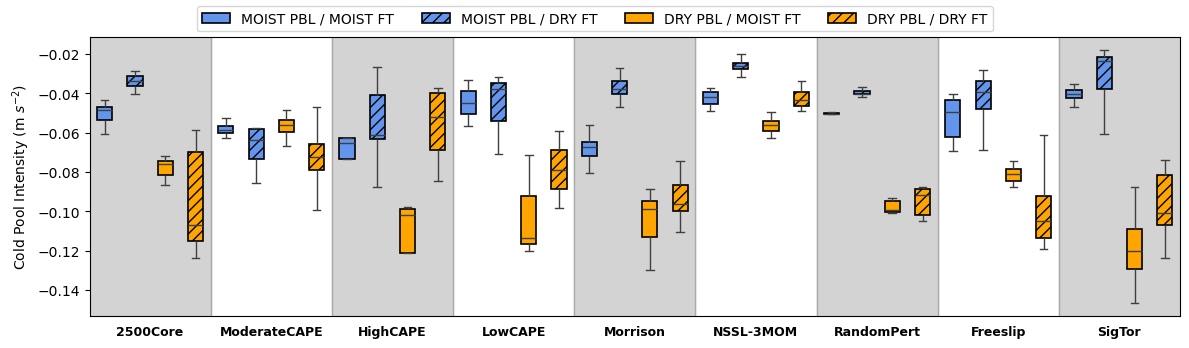

In [13]:
fig, ax = plt.subplots(figsize=(12, 3.5))

plot = b[b[sim_col].isin(INCLUDE)].copy()
order = INCLUDE

# plot = (plot.groupby(sim_col, group_keys=False).tail(60))

ax = sns.boxplot(
    data=plot,
    x=sim_col,
    y='Buoyancy',
    order=order,
    showfliers=False,
    width=0.5
)

# add separating blocks
x_positions = list(range(len(INCLUDE)))
block_starts = []
block_ends = []
cursor = 0
for block in BLOCKS:
    L = len(block)
    start = cursor
    end = cursor + L - 1
    block_starts.append(start)
    block_ends.append(end)
    if (len(block_starts) - 1) % 2 == 0:
        ax.axvspan(start - 0.5, end + 0.5, color='lightgrey', zorder=0)
    cursor += L

for end in block_ends[:-1]:
    ax.axvline(end + 0.5, color='darkgray', linewidth=1, linestyle='-', zorder=1)

for label, start, end in zip(BLOCK_LABELS, block_starts, block_ends):
    center = (start + end) / 2.0
    ax.text(center, -0.08, label, ha='center', va='bottom',
            fontsize=9, fontweight='bold', rotation=0,
            transform=ax.get_xaxis_transform())  # place relative to x-axis

ax.margins(x=0)
# ax.set_title('Buoyancy Distribution per Simulation')
ax.set_xlabel('')
# ax.set_xlabel('Simulation', labelpad=8)
ax.set_ylabel('Cold Pool Intensity (m $s^{-2}$)')
xlabels = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticks([])
ax.set_xticklabels([])
ax.tick_params(axis='x', which='both', length=0)


box_patches = [p for p in ax.patches if isinstance(p, mpatches.PathPatch)]
if not box_patches:  # fallback for some seaborn versions
    box_patches = list(ax.artists)

for patch, sim in zip(box_patches, xlabels):
    g = sim_to_group.get(sim, 'other')
    patch.set_hatch(group_to_hatch[g])
    patch.set_edgecolor('black')
    patch.set_linewidth(1.2)
    # Re-apply facecolor explicitly (some backends reset after hatch)
    patch.set_facecolor(group_to_color[g])

present_groups = [g for g in ['mm','md','dm','dd','other'] if g in sim_to_group.values()]
legend_handles = [
    mpatches.Rectangle(
        (0, 0), 1, 1,
        facecolor=group_to_color[g],
        edgecolor='black',
        hatch=group_to_hatch[g],
        linewidth=1.2,
        label=group_long_names[g]
    )
    for g in present_groups
]

fig = ax.get_figure()
fig.legend(
    handles=legend_handles,
    loc='upper center',          # place at the bottom center of the figure
    ncol=len(legend_handles),    # single row
    frameon=True,
    #title='RH Regime',
    fontsize=10,
    borderaxespad=0.5,
)

plt.tight_layout()
plt.subplots_adjust(top=0.9)


outdir = inpath
# plt.savefig(outdir / 'box_cp_intensity.pdf', bbox_inches='tight')
# plt.savefig(outdir / 'box_cp_intensity.png', dpi=300, bbox_inches='tight')

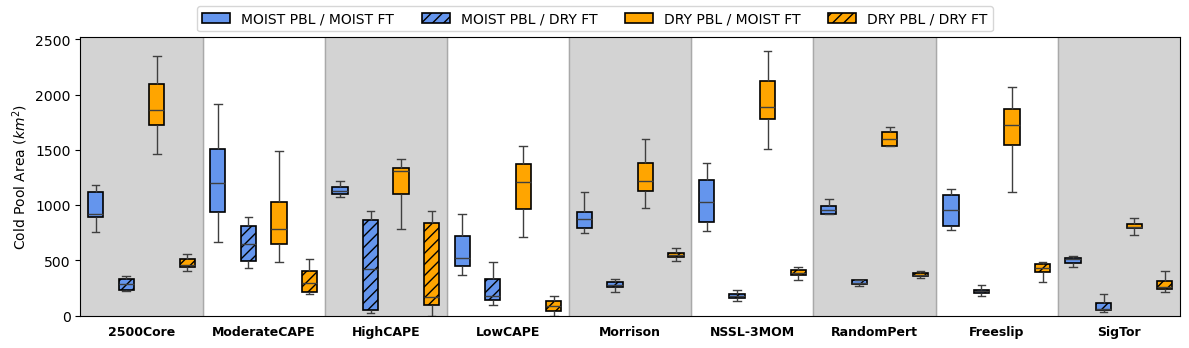

In [14]:
fig, ax = plt.subplots(figsize=(12, 3.5))

plot = area[area[sim_col].isin(INCLUDE)].copy()
order = INCLUDE

# plot = (plot.groupby(sim_col, group_keys=False).tail(60))

ax = sns.boxplot(
    data=plot,
    x=sim_col,
    y='Cold Pool Area',
    order=order,
    showfliers=False,
    width=0.5
)

# add separating blocks
x_positions = list(range(len(INCLUDE)))
block_starts = []
block_ends = []
cursor = 0
for block in BLOCKS:
    L = len(block)
    start = cursor
    end = cursor + L - 1
    block_starts.append(start)
    block_ends.append(end)
    if (len(block_starts) - 1) % 2 == 0:
        ax.axvspan(start - 0.5, end + 0.5, color='lightgrey', zorder=0)
    cursor += L

for end in block_ends[:-1]:
    ax.axvline(end + 0.5, color='darkgray', linewidth=1, linestyle='-', zorder=1)

for label, start, end in zip(BLOCK_LABELS, block_starts, block_ends):
    center = (start + end) / 2.0
    ax.text(center, -0.08, label, ha='center', va='bottom',
            fontsize=9, fontweight='bold', rotation=0,
            transform=ax.get_xaxis_transform())  # place relative to x-axis

ax.margins(x=0)
ax.set_xlabel('')
ax.set_ylabel('Cold Pool Area ($km^2$)')
xlabels = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticks([])
ax.set_xticklabels([])
ax.tick_params(axis='x', which='both', length=0)
ax.set_ylim(ymin=0)


box_patches = [p for p in ax.patches if isinstance(p, mpatches.PathPatch)]
if not box_patches:  # fallback for some seaborn versions
    box_patches = list(ax.artists)

for patch, sim in zip(box_patches, xlabels):
    g = sim_to_group.get(sim, 'other')
    patch.set_hatch(group_to_hatch[g])
    patch.set_edgecolor('black')
    patch.set_linewidth(1.2)
    # Re-apply facecolor explicitly (some backends reset after hatch)
    patch.set_facecolor(group_to_color[g])

present_groups = [g for g in ['mm','md','dm','dd','other'] if g in sim_to_group.values()]
legend_handles = [
    mpatches.Rectangle(
        (0, 0), 1, 1,
        facecolor=group_to_color[g],
        edgecolor='black',
        hatch=group_to_hatch[g],
        linewidth=1.2,
        label=group_long_names[g]
    )
    for g in present_groups
]

fig = ax.get_figure()
fig.legend(
    handles=legend_handles,
    loc='upper center',          # place at the bottom center of the figure
    ncol=len(legend_handles),    # single row
    frameon=True,
    #title='RH Regime',
    fontsize=10,
    borderaxespad=0.5,
)

plt.tight_layout()
plt.subplots_adjust(top=0.9)


outdir = inpath
# plt.savefig(outdir / 'box_cp_area.pdf', bbox_inches='tight')
# plt.savefig(outdir / 'box_cp_area.png', dpi=300, bbox_inches='tight')

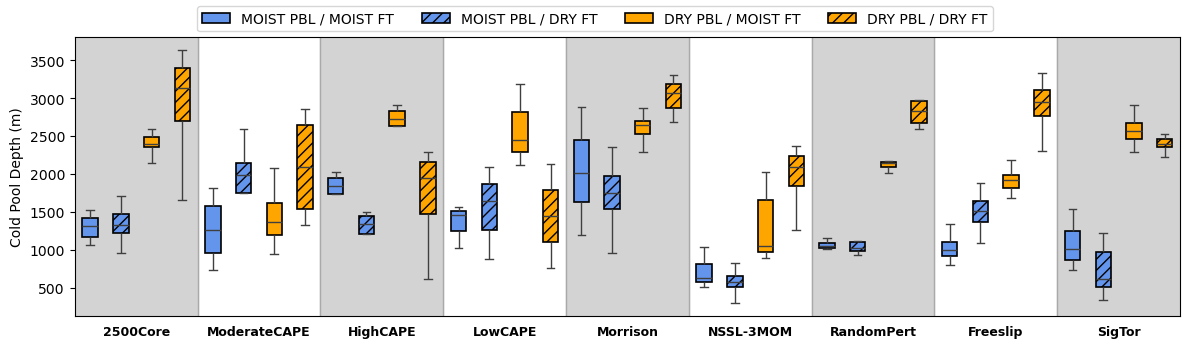

In [15]:
fig, ax = plt.subplots(figsize=(12, 3.5))

plot = depth[depth[sim_col].isin(INCLUDE)].copy()
order = INCLUDE

# plot = (plot.groupby(sim_col, group_keys=False).tail(60))

ax = sns.boxplot(
    data=plot,
    x=sim_col,
    y='Cold Pool Depth',
    order=order,
    showfliers=False,
    width=0.5
)

# add separating blocks
x_positions = list(range(len(INCLUDE)))
block_starts = []
block_ends = []
cursor = 0
for block in BLOCKS:
    L = len(block)
    start = cursor
    end = cursor + L - 1
    block_starts.append(start)
    block_ends.append(end)
    if (len(block_starts) - 1) % 2 == 0:
        ax.axvspan(start - 0.5, end + 0.5, color='lightgrey', zorder=0)
    cursor += L

for end in block_ends[:-1]:
    ax.axvline(end + 0.5, color='darkgray', linewidth=1, linestyle='-', zorder=1)

for label, start, end in zip(BLOCK_LABELS, block_starts, block_ends):
    center = (start + end) / 2.0
    ax.text(center, -0.08, label, ha='center', va='bottom',
            fontsize=9, fontweight='bold', rotation=0,
            transform=ax.get_xaxis_transform())  # place relative to x-axis

ax.margins(x=0)
ax.set_xlabel('')
ax.set_ylabel('Cold Pool Depth (m)')
xlabels = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticks([])
ax.set_xticklabels([])
ax.tick_params(axis='x', which='both', length=0)
# ax.set_ylim(ymin=0)


box_patches = [p for p in ax.patches if isinstance(p, mpatches.PathPatch)]
if not box_patches:  # fallback for some seaborn versions
    box_patches = list(ax.artists)

for patch, sim in zip(box_patches, xlabels):
    g = sim_to_group.get(sim, 'other')
    patch.set_hatch(group_to_hatch[g])
    patch.set_edgecolor('black')
    patch.set_linewidth(1.2)
    # Re-apply facecolor explicitly (some backends reset after hatch)
    patch.set_facecolor(group_to_color[g])

present_groups = [g for g in ['mm','md','dm','dd','other'] if g in sim_to_group.values()]
legend_handles = [
    mpatches.Rectangle(
        (0, 0), 1, 1,
        facecolor=group_to_color[g],
        edgecolor='black',
        hatch=group_to_hatch[g],
        linewidth=1.2,
        label=group_long_names[g]
    )
    for g in present_groups
]

fig = ax.get_figure()
fig.legend(
    handles=legend_handles,
    loc='upper center',          # place at the bottom center of the figure
    ncol=len(legend_handles),    # single row
    frameon=True,
    #title='RH Regime',
    fontsize=10,
    borderaxespad=0.5,
)

plt.tight_layout()
plt.subplots_adjust(top=0.9)

outdir = inpath
# plt.savefig(outdir / 'box_cp_depth.pdf', bbox_inches='tight')
# plt.savefig(outdir / 'box_cp_depth.png', dpi=300, bbox_inches='tight')

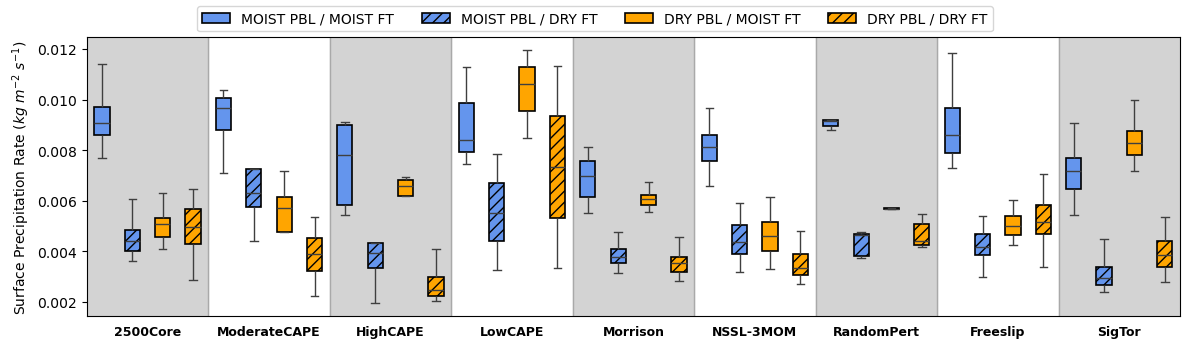

In [16]:
fig, ax = plt.subplots(figsize=(12, 3.5))

plot = prate[prate[sim_col].isin(INCLUDE)].copy()
order = INCLUDE

# plot = (plot.groupby(sim_col, group_keys=False).tail(60))

ax = sns.boxplot(
    data=plot,
    x=sim_col,
    y='Surface Precipitation Rate',
    order=order,
    showfliers=False,
    width=0.5
)

# add separating blocks
x_positions = list(range(len(INCLUDE)))
block_starts = []
block_ends = []
cursor = 0
for block in BLOCKS:
    L = len(block)
    start = cursor
    end = cursor + L - 1
    block_starts.append(start)
    block_ends.append(end)
    if (len(block_starts) - 1) % 2 == 0:
        ax.axvspan(start - 0.5, end + 0.5, color='lightgrey', zorder=0)
    cursor += L

for end in block_ends[:-1]:
    ax.axvline(end + 0.5, color='darkgray', linewidth=1, linestyle='-', zorder=1)

for label, start, end in zip(BLOCK_LABELS, block_starts, block_ends):
    center = (start + end) / 2.0
    ax.text(center, -0.08, label, ha='center', va='bottom',
            fontsize=9, fontweight='bold', rotation=0,
            transform=ax.get_xaxis_transform())  # place relative to x-axis

ax.margins(x=0)
ax.set_xlabel('')
ax.set_ylabel('Surface Precipitation Rate ($kg$ $m^{-2}$ $s^{-1}$)')
xlabels = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticks([])
ax.set_xticklabels([])
ax.tick_params(axis='x', which='both', length=0)
#ax.set_ylim(ymin=0)


box_patches = [p for p in ax.patches if isinstance(p, mpatches.PathPatch)]
if not box_patches:  # fallback for some seaborn versions
    box_patches = list(ax.artists)

for patch, sim in zip(box_patches, xlabels):
    g = sim_to_group.get(sim, 'other')
    patch.set_hatch(group_to_hatch[g])
    patch.set_edgecolor('black')
    patch.set_linewidth(1.2)
    # Re-apply facecolor explicitly (some backends reset after hatch)
    patch.set_facecolor(group_to_color[g])

present_groups = [g for g in ['mm','md','dm','dd','other'] if g in sim_to_group.values()]
legend_handles = [
    mpatches.Rectangle(
        (0, 0), 1, 1,
        facecolor=group_to_color[g],
        edgecolor='black',
        hatch=group_to_hatch[g],
        linewidth=1.2,
        label=group_long_names[g]
    )
    for g in present_groups
]

fig = ax.get_figure()
fig.legend(
    handles=legend_handles,
    loc='upper center',          # place at the bottom center of the figure
    ncol=len(legend_handles),    # single row
    frameon=True,
    #title='RH Regime',
    fontsize=10,
    borderaxespad=0.5,
)

plt.tight_layout()
plt.subplots_adjust(top=0.9)


outdir = inpath
# plt.savefig(outdir / 'box_prate.pdf', bbox_inches='tight')
# plt.savefig(outdir / 'box_prate.png', dpi=300, bbox_inches='tight')

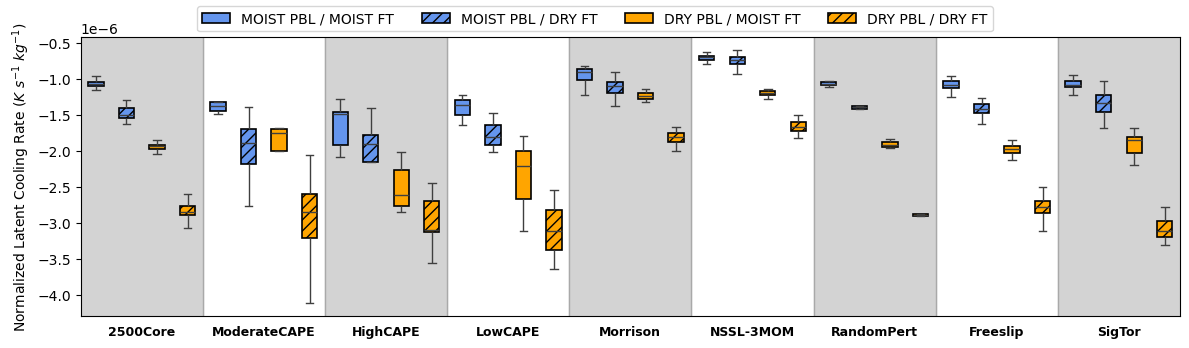

In [17]:
fig, ax = plt.subplots(figsize=(12, 3.5))

plot = lh_norm[lh_norm[sim_col].isin(INCLUDE)].copy()
order = INCLUDE

# plot = (plot.groupby(sim_col, group_keys=False).tail(60))

ax = sns.boxplot(
    data=plot,
    x=sim_col,
    y='Normalized Latent Heating',
    order=order,
    showfliers=False,
    width=0.5
)

# add separating blocks
x_positions = list(range(len(INCLUDE)))
block_starts = []
block_ends = []
cursor = 0
for block in BLOCKS:
    L = len(block)
    start = cursor
    end = cursor + L - 1
    block_starts.append(start)
    block_ends.append(end)
    if (len(block_starts) - 1) % 2 == 0:
        ax.axvspan(start - 0.5, end + 0.5, color='lightgrey', zorder=0)
    cursor += L

for end in block_ends[:-1]:
    ax.axvline(end + 0.5, color='darkgray', linewidth=1, linestyle='-', zorder=1)

for label, start, end in zip(BLOCK_LABELS, block_starts, block_ends):
    center = (start + end) / 2.0
    ax.text(center, -0.08, label, ha='center', va='bottom',
            fontsize=9, fontweight='bold', rotation=0,
            transform=ax.get_xaxis_transform())  # place relative to x-axis

ax.margins(x=0)
ax.set_xlabel('')
ax.set_ylabel('Normalized Latent Cooling Rate ($K$ $s^{-1}$ $kg^{-1}$)')
xlabels = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticks([])
ax.set_xticklabels([])
ax.tick_params(axis='x', which='both', length=0)
# ax.set_ylim(ymin=0)


box_patches = [p for p in ax.patches if isinstance(p, mpatches.PathPatch)]
if not box_patches:  # fallback for some seaborn versions
    box_patches = list(ax.artists)

for patch, sim in zip(box_patches, xlabels):
    g = sim_to_group.get(sim, 'other')
    patch.set_hatch(group_to_hatch[g])
    patch.set_edgecolor('black')
    patch.set_linewidth(1.2)
    # Re-apply facecolor explicitly (some backends reset after hatch)
    patch.set_facecolor(group_to_color[g])

present_groups = [g for g in ['mm','md','dm','dd','other'] if g in sim_to_group.values()]
legend_handles = [
    mpatches.Rectangle(
        (0, 0), 1, 1,
        facecolor=group_to_color[g],
        edgecolor='black',
        hatch=group_to_hatch[g],
        linewidth=1.2,
        label=group_long_names[g]
    )
    for g in present_groups
]

fig = ax.get_figure()
fig.legend(
    handles=legend_handles,
    loc='upper center',          # place at the bottom center of the figure
    ncol=len(legend_handles),    # single row
    frameon=True,
    #title='RH Regime',
    fontsize=10,
    borderaxespad=0.5,
)

plt.tight_layout()
plt.subplots_adjust(top=0.9)


outdir = inpath
# plt.savefig(outdir / 'box_lh_norm_full.pdf', bbox_inches='tight')
# plt.savefig(outdir / 'box_lh_norm_full.png', dpi=300, bbox_inches='tight')

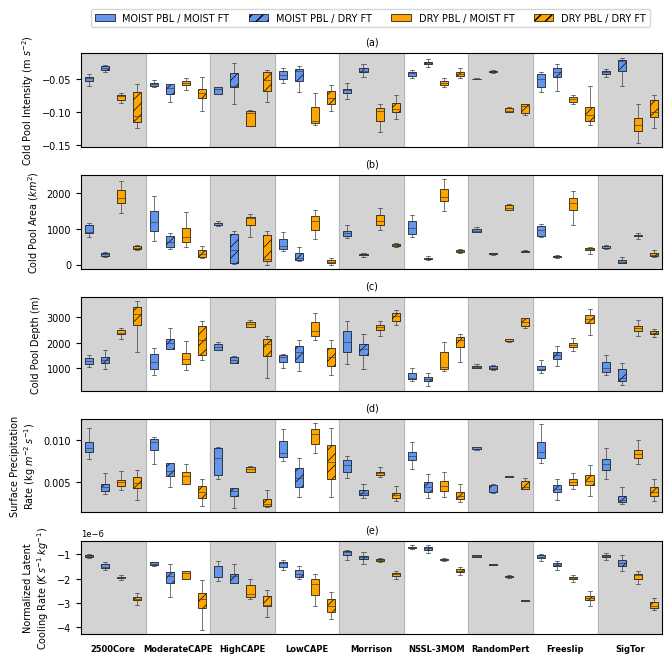

In [19]:
fig, axs = plt.subplots(5, 1, figsize=(7.5, 7))
acs = axs.flatten()

plot = b[b[sim_col].isin(INCLUDE)].copy()
order = INCLUDE
sns.boxplot(
    data=plot,
    x=sim_col,
    y='Buoyancy',
    order=order,
    showfliers=False,
    width=0.5,
    linewidth=0.5,
    ax=axs[0]
)
axs[0].set_title('(a)', fontsize=7, loc='center')
axs[0].set_xlabel('')
axs[0].set_ylabel('Cold Pool Intensity (m $s^{-2}$)', fontsize=7)


plot = area[area[sim_col].isin(INCLUDE)].copy()
order = INCLUDE
sns.boxplot(
    data=plot,
    x=sim_col,
    y='Cold Pool Area',
    order=order,
    showfliers=False,
    width=0.5,
    linewidth=0.5,
    ax=axs[1]
)
axs[1].set_title('(b)', fontsize=7, loc='center')
axs[1].set_xlabel('')
axs[1].set_ylabel('Cold Pool Area ($km^2$)', fontsize=7)


plot = depth[depth[sim_col].isin(INCLUDE)].copy()
order = INCLUDE
sns.boxplot(
    data=plot,
    x=sim_col,
    y='Cold Pool Depth',
    order=order,
    showfliers=False,
    width=0.5,
    linewidth=0.5,
    ax=axs[2]
)
axs[2].set_title('(c)', fontsize=7, loc='center')
axs[2].set_xlabel('')
axs[2].set_ylabel('Cold Pool Depth (m)', fontsize=7)


plot = prate[prate[sim_col].isin(INCLUDE)].copy()
order = INCLUDE
sns.boxplot(
    data=plot,
    x=sim_col,
    y='Surface Precipitation Rate',
    order=order,
    showfliers=False,
    width=0.5,
    linewidth=0.5,
    ax=axs[3]
)
axs[3].set_title('(d)', fontsize=7, loc='center')
axs[3].set_xlabel('')
axs[3].set_ylabel(textwrap.fill('Surface Precipitation             Rate (kg $m^{-2}\:s^{-1}$)', 35), fontsize=7)


plot = lh_norm[lh_norm[sim_col].isin(INCLUDE)].copy()
order = INCLUDE
sns.boxplot(
    data=plot,
    x=sim_col,
    y='Normalized Latent Heating',
    order=order,
    showfliers=False,
    width=0.5,
    linewidth=0.5,
    ax=axs[4]
)
for label, start, end in zip(BLOCK_LABELS, block_starts, block_ends):
    center = (start + end) / 2.0
    axs[4].text(center, -0.2, label, ha='center', va='bottom',
            fontsize=6, fontweight='bold', rotation=0,
            transform=axs[4].get_xaxis_transform())  # place relative to x-axis

axs[4].set_title('(e)', fontsize=7, loc='center')
axs[4].set_xlabel('')
xlabels = [t.get_text() for t in axs[4].get_xticklabels()]
axs[4].set_ylabel(textwrap.fill('Normalized Latent               Cooling Rate ($K\:s^{-1}\:kg^{-1}$)', 35), fontsize=7)
axs[4].yaxis.get_offset_text().set_fontsize(6)


for i in range(len(axs)):
    # add separating blocks
    x_positions = list(range(len(INCLUDE)))
    block_starts = []
    block_ends = []
    cursor = 0
    for block in BLOCKS:
        L = len(block)
        start = cursor
        end = cursor + L - 1
        block_starts.append(start)
        block_ends.append(end)
        if (len(block_starts) - 1) % 2 == 0:
            axs[i].axvspan(start - 0.5, end + 0.5, color='lightgrey', zorder=0)
        cursor += L

    for end in block_ends[:-1]:
        axs[i].axvline(end + 0.5, color='darkgray', linewidth=0.5, linestyle='-', zorder=1)

    box_patches = [p for p in axs[i].patches if isinstance(p, mpatches.PathPatch)]
    if not box_patches:  # fallback for some seaborn versions
        box_patches = list(axs[i].artists)

    for patch, sim in zip(box_patches, xlabels):
        g = sim_to_group.get(sim, 'other')
        patch.set_hatch(group_to_hatch[g])
        patch.set_hatch_linewidth(0.5)
        patch.set_edgecolor('black')
        patch.set_linewidth(0.5)
        # Re-apply facecolor explicitly (some backends reset after hatch)
        patch.set_facecolor(group_to_color[g])

    axs[i].margins(x=0)
    axs[i].set_xticks([])
    axs[i].set_xticklabels([])
    axs[i].tick_params(axis='x', which='both', length=0)
    axs[i].tick_params(axis='y', labelsize=7)

present_groups = [g for g in ['mm','md','dm','dd','other'] if g in sim_to_group.values()]
legend_handles = [
    mpatches.Rectangle(
        (0, 0), 1, 1,
        facecolor=group_to_color[g],
        edgecolor='black',
        hatch=group_to_hatch[g],
        linewidth=0.5,
        label=group_long_names[g]
    )
    for g in present_groups
]

fig.legend(
    handles=legend_handles,
    ncol=len(legend_handles),
    frameon=True,
    fontsize=7,
    borderaxespad=0.5,
    bbox_to_anchor=(0.89, 1.01)
)

plt.subplots_adjust(top=0.94)
fig.subplots_adjust(hspace=0.3)

outdir = inpath
plt.savefig(outdir / 'box_all_vars_const_thresh.pdf', bbox_inches='tight')
plt.savefig(outdir / 'box_all_vars_const_thresh.png', dpi=300, bbox_inches='tight')
plt.show()